# 04 - Combining with routes data

We will now combine and merged STATS19 dataset with the routes data.

## 1. Preparing some things first
1. Map folder names to formatted school_names column
2. Make a dataset for school_name, route_reference, accident_index, geometry.

In [19]:
# Import function modules
%load_ext autoreload
%autoreload 2

import util.data_load_tools as dlt
from pathlib import Path
import geopandas as gpd
import pandas as pd

# Main data folder path
base_path = "../data/routes/"
read_file = "stats19 with routes for SY"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load Routes-Collisions data and Convert to Dataset
The files are in gpkg format for all routes per each school, will need to make a dataset out of these.

If you want to use this again, just import this module and you can use the function `read_gpkg_data(base_path)`!

In [3]:
test = gpd.read_file("../data/routes/stats19 with routes for SY/Barnsley/Primary school analysis/merged data/All Saints Academy/joined_0.gpkg")
test.head()

,accident_reference,length_m,route_id,geometry
0,14BB00071,2625.437567,all_saints_academy_0,POINT (-1.37347 53.53829)
1,141053594,2625.437567,all_saints_academy_0,POINT (-1.38293 53.54066)
2,141162579,2625.437567,all_saints_academy_0,POINT (-1.39858 53.54356)
3,14B026506,2625.437567,all_saints_academy_0,POINT (-1.38444 53.54095)
4,14B030207,2625.437567,all_saints_academy_0,POINT (-1.38234 53.54049)


In [20]:
dlt.combine_route_files(base_dir=(base_path + read_file), 
                                     output_dir=base_path, 
                                     output_filename = "routes_df",
                                     save_format="csv")


✅ Loaded: Yewlands Academy (Sheffield) | 5730 files total                                                                      

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\util\data_load_tools.py:376: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = gpd.GeoDataFrame(pd.concat(all_data, ignore_index=True))



📊 Combined 5730 files → 63446 total rows
💾 Saved CSV (geometry dropped): ..\data\routes\routes_df.csv


,accident_reference,length_m,route_id,geometry,school_name,borough
0,14BB00071,2625.437567,all_saints_academy_0,POINT (-1.37347 53.53829),All Saints Academy,Barnsley
1,141053594,2625.437567,all_saints_academy_0,POINT (-1.38293 53.54066),All Saints Academy,Barnsley
2,141162579,2625.437567,all_saints_academy_0,POINT (-1.39858 53.54356),All Saints Academy,Barnsley
3,14B026506,2625.437567,all_saints_academy_0,POINT (-1.38444 53.54095),All Saints Academy,Barnsley
4,14B030207,2625.437567,all_saints_academy_0,POINT (-1.38234 53.54049),All Saints Academy,Barnsley
...,...,...,...,...,...,...
63441,14JJ00077,2805.790539,yewlands_academy_9,POINT (-1.49915 53.43668),Yewlands Academy,Sheffield
63442,14K219609,2805.790539,yewlands_academy_9,POINT (-1.49418 53.43729),Yewlands Academy,Sheffield
63443,14JJ01311,2805.790539,yewlands_academy_9,POINT (-1.51285 53.43664),Yewlands Academy,Sheffield
63444,14K296114,2805.790539,yewlands_academy_9,POINT (-1.50102 53.43676),Yewlands Academy,Sheffield


### 2.1. Clean up the dataset
With all the routes in one place, let's clean up the data a bit.
* convert length_m to length_km and limit to 3 decimals.
* replace accident_reference with accident_index for consistenet joining.
* check for redundant rows, empty data, etc.

In [23]:
routes_df = pd.read_csv("../data/routes/routes_df.csv")
routes_df.to_csv("../data/routes/routes_df_original.csv")

In [24]:
routes_df = pd.read_csv("../data/routes/routes_df.csv")
# Convert length_m to kilometers, round to 3 decimal places
routes_df["length_km"] = (routes_df["length_m"] / 1000).round(3)

# Drop original length_m column
routes_df.drop(columns="length_m", inplace=True)
routes_df.to_csv("../data/routes/routes_df.csv")
routes_df.head()

,accident_reference,route_id,school_name,borough,length_km
0,14BB00071,all_saints_academy_0,All Saints Academy,Barnsley,2.625
1,141053594,all_saints_academy_0,All Saints Academy,Barnsley,2.625
2,141162579,all_saints_academy_0,All Saints Academy,Barnsley,2.625
3,14B026506,all_saints_academy_0,All Saints Academy,Barnsley,2.625
4,14B030207,all_saints_academy_0,All Saints Academy,Barnsley,2.625


In [25]:
# Show missing value counts
print(routes_df.isnull().sum())
duplicates = routes_df[routes_df.duplicated(subset="accident_reference", keep=False)]
print(f"Number of duplicate accident_reference values: {len(duplicates)}")
print(routes_df.size)
# Get the duplicate accident_reference values (the IDs that appear more than once)
duplicate_ids = routes_df["accident_reference"][routes_df["accident_reference"].duplicated()].unique()

# Filter rows with these duplicate accident_reference values
dupe_rows = routes_df[routes_df["accident_reference"].isin(duplicate_ids)]

# Show the first 10 duplicates
# print(dupe_rows.sort_values("accident_reference").head(10))

accident_reference    0
route_id              0
school_name           0
borough               0
length_km             0
dtype: int64
Number of duplicate accident_reference values: 62011
317230


The large number of duplicate accidet_references is not a problem, as its most likely caused by routes overlapping, not merging issues.

## 3. Bring in STATS19 data

In [27]:
routes_df = pd.read_csv("../data/routes/routes_df.csv").copy()
stats19_df = pd.read_csv("../data/STATS19/dft_STATS19_1979_23_SY.csv", low_memory=False)
df_filtered = stats19_df[stats19_df["accident_year"] >= 2019]

# Merge accident_index from stats19 into routes_df
routes_df_n = routes_df.merge(
    df_filtered[['accident_reference', 'accident_index']],
    on='accident_reference',
    how='left'
)

# Drop accident_reference (since we have accident_index now)
routes_df_n = routes_df_n.drop(columns='accident_reference')
desired_order = [
    "accident_index", 
    "route_id", 
    "school_name", 
    "borough", 
    "length_km" 
]
routes_df_n = routes_df_n[desired_order]
# Check result
routes_df_n.head()
routes_df_n.shape


(69582, 5)

In [10]:
routes_df_n.to_csv("../data/routes/routes_df.csv")


In [28]:
# Perform the merge
merged_df = df_filtered.merge(
    routes_df_n,
    on="accident_index",
    how="inner"  # keeps all stats19 rows, adds route info where available
)

# Check result
print(merged_df.shape)
merged_df.head()


(44482, 89)


,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,escooter_flag,dir_from_e,dir_from_n,dir_to_e,dir_to_n,driver_distance_banding,route_id,school_name,borough,length_km
0,2019140806065,2019,140806065,1,1,3,2,15,3,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
1,2019140806065,2019,140806065,1,1,3,2,15,3,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
2,2019140806065,2019,140806065,1,1,3,2,15,3,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
3,2019140806065,2019,140806065,1,1,3,2,15,3,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
4,2019140806065,2019,140806065,1,1,3,2,15,3,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_7,Barnsley College,Barnsley,5.425


In [29]:
merged_df.to_csv("../data/stats19_routes_combined.csv")

## Explore the new dataset:Collision Overlap summary
Let's look at how collisions are duplicated in multiples routes.

In [30]:
# autoreload setup
%load_ext autoreload
%autoreload 2

# imports
import util.dataset_stats as dfs
import pandas as pd

df = pd.read_csv('../data/stats19_routes_combined.csv', low_memory=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
high = df[df['school_name'] == 'Thrybergh Academy']
# display(high)
print(len(high))

403


📊 Averages:
• Avg collisions per route: 14.72
• Avg collisions per km: 4.12
• Avg collisions per school: 107.44

🏆 Top Routes by Collision Count:
                                    route_id                                     school  collisions
                        brinsworth_academy_4                         Brinsworth Academy        2321
handsworth_grange_community_sports_college_6 Handsworth Grange Community Sports College        2313
                        ballifield_primary_2                         Ballifield Primary         868
                         athelstan_primary_2                          Athelstan Primary         867
                        ballifield_primary_3                         Ballifield Primary         867
                   waverley_junior_academy_1                    Waverley Junior Academy         867
                 astrea_academy_woodfields_1                  Astrea Academy Woodfields         522
               sir_thomas_wharton_academy_16          

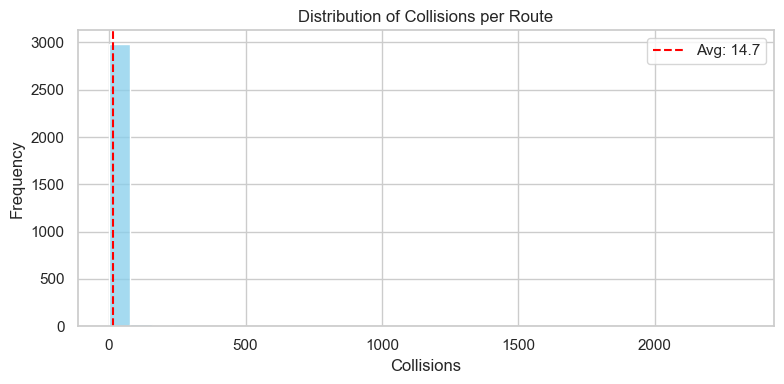

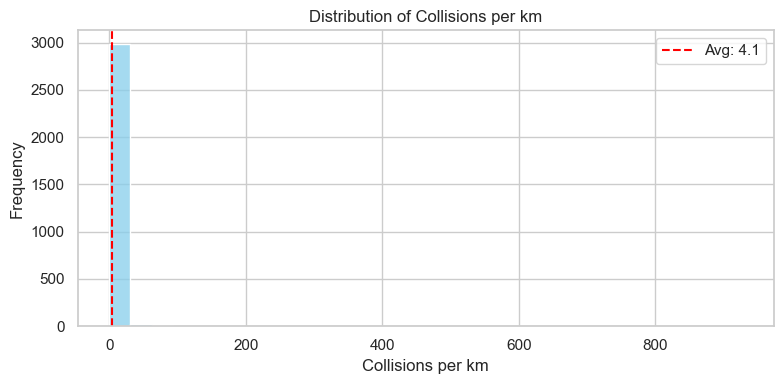

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\util\dataset_stats.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df.sort_values(x), palette=color)


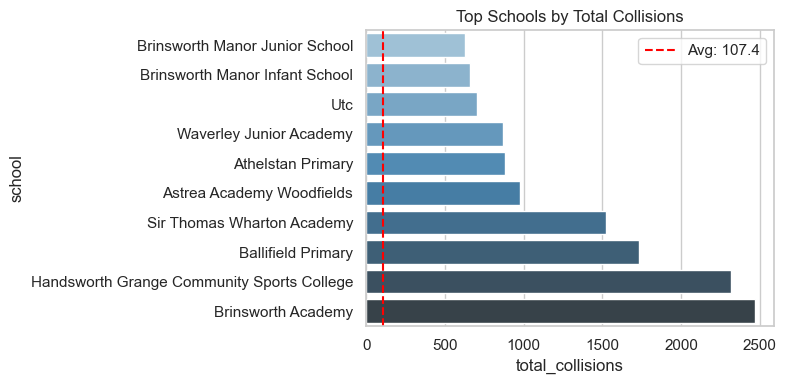

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\util\dataset_stats.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df.sort_values(x), palette=color)


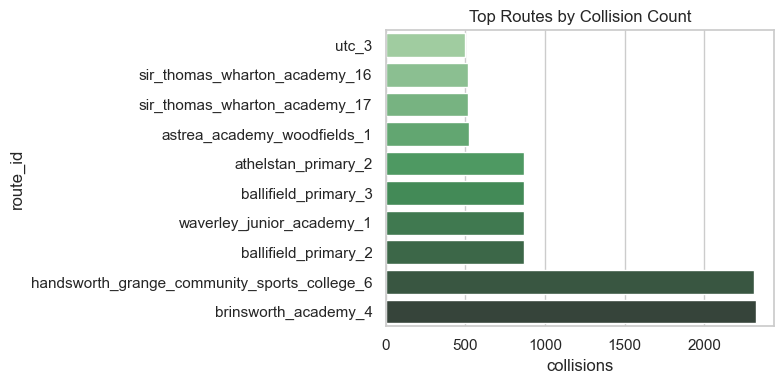

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\util\dataset_stats.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x, y=y, data=df.sort_values(x), palette=color)


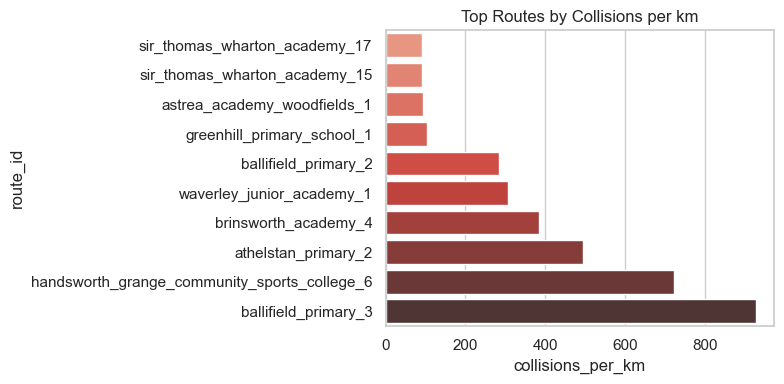

In [32]:
# dfs.collision_overlap_summary(df)
dfs.summarise_and_visualise_route_school_stats(df)